Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0158 - val_loss: 0.0029
Epoch 2/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - val_loss: 0.0017
Epoch 3/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 4/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 5/5
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8.8060e-04 - val_loss: 7.4092e-04
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.4092e-04 
Test Loss: 0.0007409182726405561
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
Predicted next value: [[0.604684]]


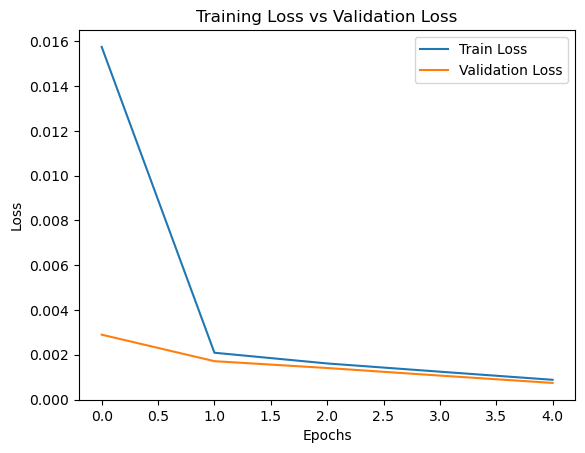

In [7]:
import numpy as np 
import tensorflow as tf 
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import SimpleRNN, Dense 
import matplotlib.pyplot as plt

def generate_sequence(seq_length=5, num_samples=1000):
    X = []
    y = []
    for _ in range(num_samples): 
        seq = np.random.rand(seq_length) 
        X.append(seq) 
        y.append(seq[-1] + 0.1)
    return np.array(X), np.array(y)

seq_length = 5

X, y = generate_sequence(seq_length)

X = X.reshape((X.shape[0], seq_length, 1))

split = int(0.8 * len(X))
X_train, y_train = X[:split], y[:split]
X_test, y_test = X[split:], y[split:]

model = Sequential([
    SimpleRNN(10, activation='relu', input_shape=(seq_length, 1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

model.summary()

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=16,
    validation_data=(X_test, y_test)
)

test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")

sample_input = np.array([0.1, 0.2, 0.3, 0.4, 0.5]).reshape(1, seq_length, 1)
predicted_value = model.predict(sample_input)
print(f"Predicted next value: {predicted_value}")

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs Validation Loss')
plt.legend()
plt.show()